<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Conversores AD e DA</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 02 de fevereiro de 2026
</div>

<div style="page-break-after: always;"></div>

<style>
#toc ol {
  counter-reset: item;
  list-style-type: none;
  padding-left: 1.2em;
}
#toc li {
  display: block;
}
#toc li:before {
  content: counters(item, ".") " ";
  counter-increment: item;
}
</style>

<div id="toc">
  <h2>Sumário</h2>
  <ol>
    <li><a href="#1-introdução">Introdução</a></li>
    <li>
      <a href="#2-desenvolvimento">Desenvolvimento</a>
      <ol>
          <li><a href="#21-adc">ADC</a></li>
          <li><a href="#22-dac">DAC</a></li>
      </ol>
    </li>
    <li>
      <a href="#3-resultados-e-discussões">Resultados e discussões</a>
      <ol>
          <li><a href="#31-adc">ADC</a></li>
          <li><a href="#32-dac">DAC</a></li>
      </ol>
    </li>
    <li><a href="#referencias">Referências</a></li>
  </ol>
</div>

<div style="page-break-after: always;"></div>

<a id="1-introdução"></a>
# 1. Introdução

O avanço das tecnologias digitais e das comunicações tem impulsionado a necessidade de compreender, de forma cada vez mais detalhada, os processos de conversão entre sinais analógicos e digitais. Nesse contexto, os conversores analógico-digitais (ADC) e digital-analógicos (DAC) desempenham papel fundamental, pois estabelecem a interface entre o mundo físico contínuo e os sistemas computacionais discretos. A correta modelagem e análise desses dispositivos permitem avaliar os impactos de suas limitações práticas.

Este relatório tem como objetivo apresentar uma abordagem inicial para a implementação e simulação de ADCs e DACs em ambiente computacional, utilizando a linguagem Python. A proposta consiste em desenvolver modelos que representem tanto o funcionamento ideal desses dispositivos quanto suas imperfeições reais, possibilitando o estudo dos efeitos causados em sinais de diferentes naturezas. A partir dessa modelagem, busca-se compreender como parâmetros como resolução, taxa de amostragem e filtros de reconstrução influenciam diretamente métricas demétricas de desempenho, incluindo a taxa de erro de bits (BER) em sistemas de comunicação.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

plt.style.use('seaborn-v0_8')

<a id="2-desenvolvimento"></a>
# 2. Desenvolvimento

<a id="21-adc"></a>
## 2.1 Modelagem do ADC

Para a modelagem do conversor analógico-digital (ADC), considera-se inicialmente um sinal analógico representado numericamente por um sinal discretizado em alta taxa de amostragem `f_orig`, significativamente superior à taxa de amostragem do ADC `fs` (ou, idealmente, múltipla desta). Dessa forma, o sinal original pode ser interpretado como uma aproximação suficientemente fiel de um sinal contínuo no tempo.

A função `adc()` implementa o comportamento essencial de um conversor analógico-digital real, contemplando as seguintes etapas:

### Adição de Ruído Térmico

Antes da amostragem, adiciona-se ao sinal um ruído térmico modelado como um processo aleatório Gaussiano de média nula. A variância do ruído é definida em função do tamanho do passo de quantização (LSB — *Least Significant Bit*):

$$
LSB = \frac{V_{max} - V_{min}}{2^N}
$$

onde:
- $V_{max}$ e $V_{min}$ representam os limites dinâmicos do ADC,
- $N$ é a resolução em bits.

A variância do ruído térmico é definida como:

$$
\sigma^2 = (0.3 \cdot LSB)
$$

ou seja, o desvio padrão do ruído corresponde a 30% do valor de um LSB. Essa escolha garante que o ruído influencie o desempenho do conversor sem dominar completamente o erro de quantização.

O sinal ruidoso pode então ser descrito como:

$$
x_{ruidoso}(t) = x(t) + n(t)
$$

onde $n(t) \sim \mathcal{N}(0, \sigma^2)$.

### Amostragem

O sinal ruidoso é amostrado à taxa `fs`. Considerando que `f_orig` é múltipla de `fs`, a amostragem é implementada por decimação do vetor original:

$$
x[n] = x_{ruidoso}(t_n)
$$

onde $t_n = \frac{n}{f_s}$.

Também é armazenado o sinal ideal amostrado (sem ruído) para posterior cálculo do erro.

### Quantização

Os valores amostrados são aproximados para o nível de quantização mais próximo dentro da faixa dinâmica do ADC. O intervalo entre níveis é dado por:

$$
\Delta = \frac{V_{max} - V_{min}}{2^N}
$$

Cada amostra é associada a um nível inteiro $k$ tal que:

$$
k = \left\lfloor \frac{x[n] - V_{min}}{\Delta} \right\rfloor
$$

O valor quantizado é então reconstruído como o ponto médio do intervalo correspondente:

$$
x_q[n] = V_{min} + k\Delta + \frac{\Delta}{2}
$$

### Codificação Digital (Mapeamento Gray)

Cada nível quantizado é convertido em uma palavra digital de $N$ bits utilizando codificação Gray. O código Gray é obtido a partir do valor binário natural $k$ por:

$$
Gray = k \oplus (k >> 1)
$$

onde:
- $>> 1$ representa deslocamento de bits à direita,
- $\oplus$ representa a operação XOR bit a bit.

### Cálculo do Erro

O erro do ADC é definido como:

$$
e[n] = x_{ideal}[n] - x_q[n]
$$

Esse erro inclui:
- erro de quantização,
- contribuição do ruído térmico,
- possíveis efeitos de saturação.

### Relação Sinal-Ruído (SNR)

A SNR é calculada como a razão entre a potência média do sinal ideal amostrado e a potência média do erro:

$$
SNR = \frac{P_{sinal}}{P_{erro}}
$$

onde:

$$
P_{sinal} = \frac{1}{N_s} \sum_{n=0}^{N_s-1} x_{ideal}^2[n]
$$

$$
P_{erro} = \frac{1}{N_s} \sum_{n=0}^{N_s-1} e^2[n]
$$

Em decibéis:

$$
SNR_{dB} = 10 \log_{10} \left( \frac{P_{sinal}}{P_{erro}} \right)
$$

### Número Efetivo de Bits (ENOB)

O ENOB (*Effective Number of Bits*) quantifica a resolução efetiva do ADC considerando ruídos e imperfeições. Ele é obtido a partir da SNR por:

$$
ENOB = \frac{SNR_{dB} - 1.76}{6.02}
$$

Essa expressão deriva do modelo teórico de um ADC ideal, cuja SNR é dada por:

$$
SNR_{ideal} = 6.02N + 1.76 \quad [dB]
$$

Assim, o ENOB representa quantos bits ideais seriam necessários para produzir a mesma SNR observada.

In [ ]:
def adc(x_t, fs, f_orig, res, adc_min = 0, adc_max = 0):
    """
    Function that simulates the behavior of an ADC, includind quantization and termic noise.

    Parameters:
        x_t: array_like
            Input analog signal
        fs: float
            Sampling frequency of the adc. Must be much smaller than f_orig [Hz]
        f_orig: float
            Sampling frequency of the input signal x_t. Much be much higher than fs [Hz]
        res: int
            Resolution of the adc [bits]
        adc_min: float
            Minimal value read by the adc. If not given, adc_min = min(x_t)
        adc_max: float
            Maximal value read by hte adc. If not given, adc_max = max(x_t)
    Returns:
        quantized_x: array_like
            Quantized signal after adc
        digital_x: list of list of int
            Digital representation of the quantized signal, in binary form
        err: array_like
            Quantization error, defined as ideal_x - quantized_x
    """

    if adc_min == 0: adc_min = np.min(x_t)
    if adc_max == 0: adc_max = np.max(x_t)
    LSB = (adc_max - adc_min)/2**res
    sigma = 0.3*LSB
    x_t_noisy = x_t + np.random.normal(0, sigma, len(x_t))
    interval = (adc_max-adc_min)/2**res
    k = round(f_orig/fs)

    ideal_x = x_t[::k]
    discrete_x = x_t_noisy[::k]
    quantized_x = np.zeros_like(discrete_x)

    digital_x = []

    for j in range(len(discrete_x)):
        level = int((discrete_x[j]-adc_min) / interval)
        if level >= 2**res: level = 2**res - 1
        quantized_x[j] = adc_min + level*interval + interval/2
        symbol = level ^ (level >> 1) 
        digital_x.append(list(map(int, bin(symbol)[2:].zfill(res))))
    
    err = ideal_x-quantized_x
    SNR = 10*np.log10(np.mean(ideal_x**2)/np.mean(err**2))
    ENOB = (SNR-1.76)/6.02
    print(f'SNR: {SNR:.2f} dB')
    print(f'ENOB: {ENOB:.2f} bits')
    return quantized_x, digital_x, err

SNR: 46.04 dB
ENOB: 7.36 bits
[[0, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 1, 0, 0], [1, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 0, 1, 0, 0], [1, 0, 0, 0, 0, 1, 0, 1], [1, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 1, 1, 1], [1, 0, 0, 1, 0, 1, 0, 0], [1, 0, 1, 0, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 0, 1, 0, 0], [0, 0, 1, 0, 1, 1, 1, 1], [0, 0, 0, 1, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 1], [0, 0, 0, 1, 1, 1, 0, 0], [0, 0, 1, 0, 1, 1, 1, 0], [0, 1, 1, 1, 0, 1, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 0, 1, 0, 0], [1, 0, 1, 0, 1, 1, 1, 0], [1, 0, 0, 1, 0, 1, 0, 0], [1, 0, 0, 0, 0, 1, 0, 1], [1, 0, 0, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 1, 0, 1], [1, 0, 0, 1, 0, 1, 0, 0], [1, 0, 1, 0, 1, 1, 1, 0], [1, 1, 1, 1, 0, 1, 0, 0], [0, 1, 0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 0, 1, 0, 0], [0, 0, 1, 0, 1, 1, 1, 0], [0, 0, 0, 1, 0, 1, 0, 0], [0, 0, 0, 0, 0, 1, 0, 1], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 1], [0, 0, 

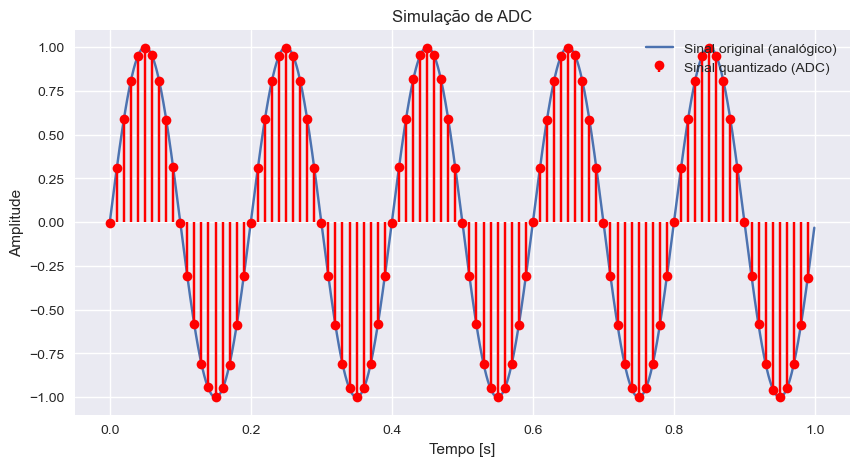

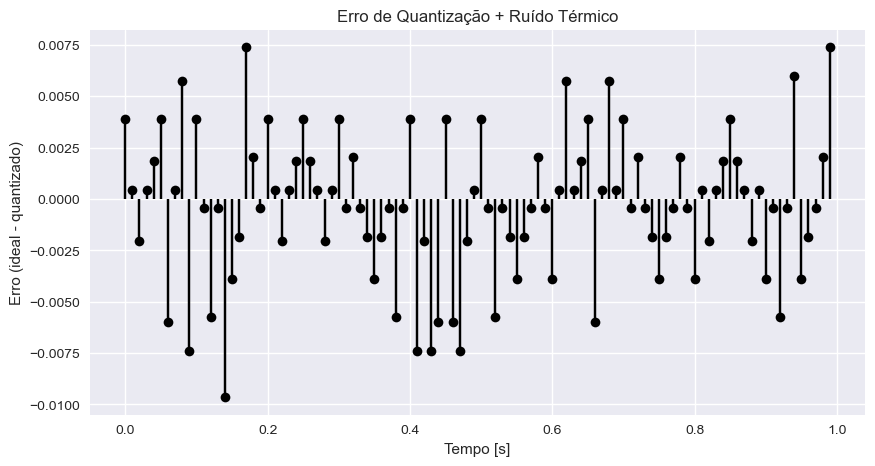

In [8]:
f_signal = 5 # frequência do sinal [Hz] 
f_orig = 1000 # frequência de amostragem original [Hz] 
t = np.linspace(0, 1, f_orig, endpoint=False) 
x_t = np.sin(2*np.pi*f_signal*t) # sinal senoidal 

# --- Aplicar ADC --- #
fs = 100 # frequência de amostragem do ADC [Hz] 
res = 8 # resolução em bits 

quantized_x, digital_x, err = adc(x_t, fs, f_orig, res, -1, 1)
print(digital_x) 


k = round(f_orig/fs)
t_adc = t[::k]  
plt.figure(figsize=(10,5))
plt.plot(t, x_t, label="Sinal original (analógico)")
plt.stem(t_adc, quantized_x,
         linefmt='r-', markerfmt='ro', basefmt=' ',
         label="Sinal quantizado (ADC)")
plt.xlabel("Tempo [s]")
plt.ylabel("Amplitude")
plt.title("Simulação de ADC")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.stem(t_adc, err,
         linefmt='k-', markerfmt='ko', basefmt=' ')
plt.xlabel("Tempo [s]")
plt.ylabel("Erro (ideal - quantizado)")
plt.title("Erro de Quantização + Ruído Térmico")
plt.grid(True)
plt.show()